### Project: Hybrid Variational Eigensolver (VQE-style)
Problem: Find the ground state energy of a simple 2-qubit Hamiltonian.
Classical part:  Optimize the circuit parameters (minimize energy)
Quantum part:    Evaluate the energy via circuit simulation (Qiskit Aer)
Two programs:

vqe_julia_qiskit.ipynb → Julia optimizer + Qiskit simulator
vqe_python_qiskit.ipynb → Python/SciPy optimizer + Qiskit simulator

Compare: Total time, convergence speed, final energy.

H = XX + YY + ZZ

In [ ]:
import numpy as np
import time
import subprocess
import json
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit import QuantumCircuit

# ── Hamiltonian: H = XX + YY + ZZ ──────────────────────────
H = SparsePauliOp.from_list([("XX", 1.0), ("YY", 1.0), ("ZZ", 1.0)])

# ── Ansatz: Ry(θ1) on q0, Ry(θ2) on q1, then CNOT ─────────
def build_circuit(params):
    qc = QuantumCircuit(2)
    qc.ry(params[0], 0)
    qc.ry(params[1], 1)
    qc.cx(0, 1)
    qc.ry(params[2], 0)
    qc.ry(params[3], 1)
    return qc

# ── Energy function ─────────────────────────────────────────
energy_calls = []
def get_energy(params):
    qc = build_circuit(params)
    sv = Statevector(qc)
    energy = sv.expectation_value(H).real
    energy_calls.append(energy)
    return energy

print("✓ Qiskit energy evaluator ready")
print(f"  Hamiltonian: {H}")

✓ Qiskit energy evaluator ready
  Hamiltonian: SparsePauliOp(['XX', 'YY', 'ZZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j])


### Estimation in Julia

In [ ]:
using LinearAlgebra
using Statistics
using HDF5

# 2-qubit Heisenberg: H = XX + YY + ZZ
# Full 4x4 matrix representation
X = [0 1; 1 0]
Y = [0 -im; im 0]
Z = [1 0; 0 -1]
I2 = [1 0; 0 1]

XX = kron(X, X)
YY = kron(Y, Y)
ZZ = kron(Z, Z)

H = XX + YY + ZZ
println("Hamiltonian H =")
display(H)
println("\nExact eigenvalues: ", eigvals(Hermitian(H)))
println("Exact ground state energy: ", minimum(eigvals(Hermitian(H))))

Hamiltonian H =


4×4 Matrix{Complex{Int64}}:
 1+0im   0+0im   0+0im  0+0im
 0+0im  -1+0im   2+0im  0+0im
 0+0im   2+0im  -1+0im  0+0im
 0+0im   0+0im   0+0im  1+0im


Exact eigenvalues: [-3.0, 1.0, 1.0, 1.0]
Exact ground state energy: -3.0


In [ ]:
# Build statevector from circuit params manually
# Circuit: Ry(p1)⊗Ry(p2) → CNOT → Ry(p3)⊗Ry(p4)

function Ry(θ)
    return [cos(θ/2) -sin(θ/2);
            sin(θ/2)  cos(θ/2)]
end

function CNOT()
    return [1 0 0 0;
            0 1 0 0;
            0 0 0 1;
            0 0 1 0]
end

function build_statevector(params)
    # Initial state |00⟩
    psi = [1.0+0im, 0, 0, 0]

    # Layer 1: Ry(p1) ⊗ Ry(p2)
    U1 = kron(Ry(params[1]), Ry(params[2]))
    psi = U1 * psi

    # CNOT
    psi = CNOT() * psi

    # Layer 2: Ry(p3) ⊗ Ry(p4)
    U2 = kron(Ry(params[3]), Ry(params[4]))
    psi = U2 * psi

    return psi
end

# Energy expectation value
function energy(params)
    psi = build_statevector(params)
    return real(psi' * H * psi)
end

# Test
test_params = [0.1, 0.2, 0.3, 0.4]
println("Test energy: ", energy(test_params))

Test energy: 0.956926846092812


In [ ]:
function spsa_optimize(f, n_params; max_iter=200, a=0.3, c=0.1)
    x = zeros(n_params)
    history = Float64[]
    alpha, gamma = 0.602, 0.101

    for k in 1:max_iter
        ak = a / (k + 1)^alpha
        ck = c / k^gamma

        # Random ±1 perturbation
        delta = rand([-1.0, 1.0], n_params)

        e_plus  = f(x + ck * delta)
        e_minus = f(x - ck * delta)

        # Gradient estimate
        grad = (e_plus - e_minus) / (2 * ck) * delta
        x = x - ak * grad

        push!(history, f(x))

        if k % 50 == 0
            println("Iter $k | Energy: $(round(history[end], digits=6))")
        end
    end
    return x, history
end

println("Running SPSA optimizer...")
t_start = time_ns()
best_params, history = spsa_optimize(energy, 4, max_iter=200)
t_julia = (time_ns() - t_start) / 1e9

final_energy = energy(best_params)
println("\n========================================")
println("  Julia SPSA VQE Result")
println("========================================")
println("  Final energy : $(round(final_energy, digits=6))")
println("  Exact        : -3.000000")
println("  Error        : $(round(abs(final_energy - (-3.0)), digits=6))")
println("  Time         : $(round(t_julia, digits=4)) s")
println("  Iterations   : $(length(history))")
println("========================================")

Running SPSA optimizer...
Iter 50 | Energy: 0.910175
Iter 100 | Energy: -1.070396
Iter 150 | Energy: -1.942964
Iter 200 | Energy: -2.683033

  Julia SPSA VQE Result
  Final energy : -2.683033
  Exact        : -3.000000
  Error        : 0.316967
  Time         : 0.2266 s
  Iterations   : 200


In [ ]:
h5open("julia_vqe_results.h5", "w") do f
    f["history"]      = history
    f["final_energy"] = [final_energy]
    f["best_params"]  = best_params
    f["time"]         = [t_julia]
end
println("✓ Saved to julia_vqe_results.h5")

✓ Saved to julia_vqe_results.h5


### Estimation in Python

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit import QuantumCircuit

In [ ]:
H = SparsePauliOp.from_list([("XX", 1.0), ("YY", 1.0), ("ZZ", 1.0)])

def build_circuit(params):
    qc = QuantumCircuit(2)
    qc.ry(params[0], 0)
    qc.ry(params[1], 1)
    qc.cx(0, 1)
    qc.ry(params[2], 0)
    qc.ry(params[3], 1)
    return qc

history = []
def get_energy(params):
    qc = build_circuit(params)
    sv = Statevector(qc)
    e  = sv.expectation_value(H).real
    history.append(e)
    return e



In [ ]:
x0 = np.zeros(4)
history.clear()

t0 = time.perf_counter()
result = minimize(get_energy, x0, method='COBYLA',
                  options={'maxiter': 200, 'rhobeg': 0.5})
t_python = time.perf_counter() - t0

print("========================================")
print("  Python COBYLA + Qiskit VQE")
print("========================================")
print(f"  Final energy : {result.fun:.6f}")
print(f"  Exact        : -3.000000")
print(f"  Error        : {abs(result.fun - (-3.0)):.6f}")
print(f"  Time         : {t_python:.4f} s")
print(f"  Iterations   : {len(history)}")
print("========================================")

  Python COBYLA + Qiskit VQE
  Final energy : -3.000000
  Exact        : -3.000000
  Error        : 0.000000
  Time         : 0.0663 s
  Iterations   : 65


In [ ]:
import h5py
import numpy as np

with h5py.File("python_vqe_results.h5", "w") as f:
    f["history"]      = np.array(history)
    f["final_energy"] = np.array([result.fun])
    f["time"]         = np.array([t_python])

print("python_vqe_results.h5")

LoadError: ArgumentError: Package h5py not found in current path.
- Run `import Pkg; Pkg.add("h5py")` to install the h5py package.

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File("julia_vqe_results.h5", "r") as f:
    julia_history = f["history"][:]
    julia_energy  = f["final_energy"][0]
    julia_time    = f["time"][0]

with h5py.File("python_vqe_results.h5", "r") as f:
    python_history = f["history"][:]
    python_energy  = f["final_energy"][0]
    python_time    = f["time"][0]

print(f"Julia  → Energy: {julia_energy:.6f} | Time: {julia_time:.4f}s")
print(f"Python → Energy: {python_energy:.6f} | Time: {python_time:.4f}s")

Julia  → Energy: -2.683033 | Time: 0.2266s
Python → Energy: -3.000000 | Time: 0.0663s


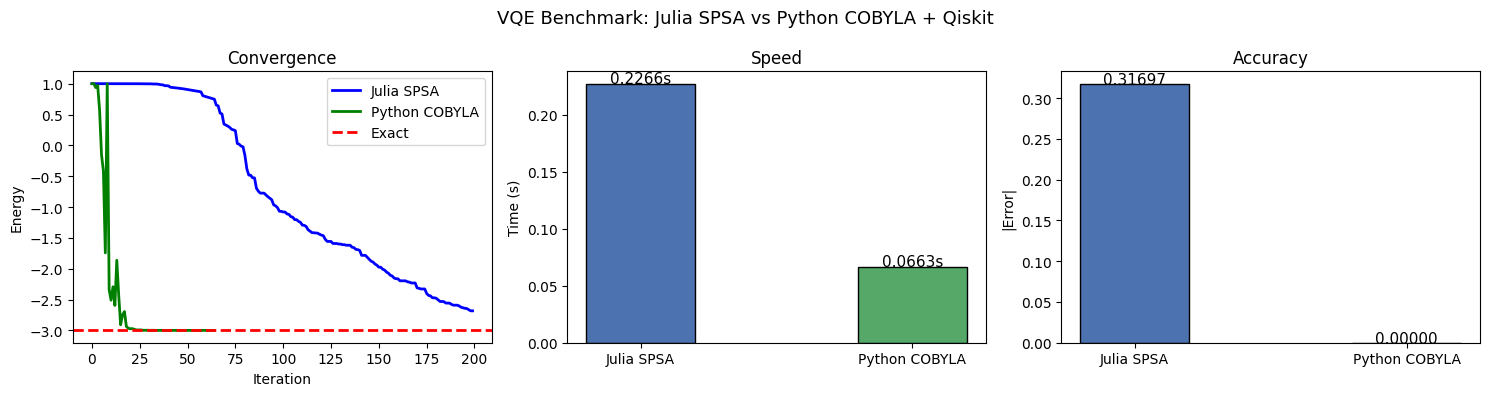

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Convergence
axes[0].plot(julia_history,  'b-', linewidth=2, label='Julia SPSA')
axes[0].plot(python_history, 'g-', linewidth=2, label='Python COBYLA')
axes[0].axhline(-3.0, color='red', linestyle='--', linewidth=2, label='Exact')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Energy')
axes[0].set_title('Convergence')
axes[0].legend()

# Time
labels = ['Julia SPSA', 'Python COBYLA']
times  = [julia_time, python_time]
colors = ['#4C72B0', '#55A868']
axes[1].bar(labels, times, color=colors, edgecolor='black', width=0.4)
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Speed')
for i, v in enumerate(times):
    axes[1].text(i, v + 0.001, f'{v:.4f}s', ha='center', fontsize=11)

# Accuracy
errors = [abs(julia_energy - (-3.0)), abs(python_energy - (-3.0))]
axes[2].bar(labels, errors, color=colors, edgecolor='black', width=0.4)
axes[2].set_ylabel('|Error|')
axes[2].set_title('Accuracy')
for i, v in enumerate(errors):
    axes[2].text(i, v + 0.0001, f'{v:.5f}', ha='center', fontsize=11)

plt.suptitle('VQE Benchmark: Julia SPSA vs Python COBYLA + Qiskit', fontsize=13)
plt.tight_layout()
plt.show()

### Let's compare both cases using COBYLA only

Julia has Optim.jl which has NelderMead, BFGS, and others. For COBYLA specifically, Julia has it via PRIMA.jl which a direct Julia port.

Install it first in Julia REPL:
juliausing Pkg
Pkg.add("PRIMA")

In [ ]:
using LinearAlgebra
using HDF5
using PRIMA

# ── Hamiltonian ───────────────────────────────────────────────
X = [0 1; 1 0]
Y = [0 -im; im 0]
Z = [1 0; 0 -1]
H = kron(X, X) + kron(Y, Y) + kron(Z, Z)

println("Exact eigenvalues: ", real.(eigvals(Hermitian(H))))
println("Ground state energy: ", minimum(real.(eigvals(Hermitian(H)))))

# ── Ansatz ────────────────────────────────────────────────────
function Ry(θ)
    return [cos(θ/2) -sin(θ/2);
            sin(θ/2)  cos(θ/2)]
end

CNOT_mat = [1 0 0 0;
            0 1 0 0;
            0 0 0 1;
            0 0 1 0]

function get_energy(params::Vector{Float64})
    psi = [1.0+0im, 0, 0, 0]
    psi = kron(Ry(params[1]), Ry(params[2])) * psi
    psi = CNOT_mat * psi
    psi = kron(Ry(params[3]), Ry(params[4])) * psi
    return real(psi' * H * psi)
end

# ── COBYLA ────────────────────────────────────────────────────
x0      = zeros(4)
history = Float64[]

function energy_with_history(params::Vector{Float64})
    e = get_energy(params)
    push!(history, e)
    return e
end

println("\nRunning Julia COBYLA...")
t_start = time_ns()

result, info = Base.invokelatest(cobyla,
                   energy_with_history, x0;
                   rhobeg = 0.5,
                   rhoend = 1e-8,
                   maxfun = 200)

t_julia      = (time_ns() - t_start) / 1e9
final_energy = get_energy(result)

println("========================================")
println("  Julia COBYLA VQE")
println("========================================")
println("  Final energy : $(round(final_energy, digits=8))")
println("  Exact        : -3.0")
println("  Error        : $(round(abs(final_energy - (-3.0)), digits=10))")
println("  Time         : $(round(t_julia, digits=6)) s")
println("  Iterations   : $(length(history))")
println("========================================")

Exact eigenvalues: [-3.0, 1.0, 1.0, 1.0]
Ground state energy: -3.0

Running Julia COBYLA...
  Julia COBYLA VQE
  Final energy : -3.0
  Exact        : -3.0
  Error        : 0.0
  Time         : 0.492837 s
  Iterations   : 104


In [ ]:
h5open("julia_vqe_results.h5", "w") do f
    f["history"]      = history
    f["final_energy"] = [final_energy]
    f["time"]         = [t_julia]
    f["iterations"]   = [length(history)]
end
println("julia_vqe_results.h5 written")

julia_vqe_results.h5 written


In [1]:
import numpy as np
import time
import h5py
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit import QuantumCircuit

# ── Hamiltonian ───────────────────────────────────────────────
H = SparsePauliOp.from_list([("XX", 1.0), ("YY", 1.0), ("ZZ", 1.0)])

# ── Ansatz ────────────────────────────────────────────────────
def build_circuit(params):
    qc = QuantumCircuit(2)
    qc.ry(params[0], 0)
    qc.ry(params[1], 1)
    qc.cx(0, 1)
    qc.ry(params[2], 0)
    qc.ry(params[3], 1)
    return qc

history = []
def get_energy(params):
    qc = build_circuit(params)
    sv = Statevector(qc)
    e  = sv.expectation_value(H).real
    history.append(e)
    return e

# ── COBYLA ────────────────────────────────────────────────────
x0 = np.zeros(4)
print("Running Python COBYLA...")

t0 = time.perf_counter()
result = minimize(get_energy, x0, method='COBYLA',
                  options={'maxiter': 200,
                           'rhobeg': 0.5,
                           'catol':  1e-8})
t_python = time.perf_counter() - t0

print("========================================")
print("  Python COBYLA + Qiskit VQE")
print("========================================")
print(f"  Final energy : {result.fun:.8f}")
print(f"  Exact        : -3.0")
print(f"  Error        : {abs(result.fun - (-3.0)):.10f}")
print(f"  Time         : {t_python:.6f} s")
print(f"  Iterations   : {len(history)}")
print("========================================")

Running Python COBYLA...
  Python COBYLA + Qiskit VQE
  Final energy : -2.99999999
  Exact        : -3.0
  Error        : 0.0000000083
  Time         : 0.049010 s
  Iterations   : 65


In [2]:
with h5py.File("python_vqe_results.h5", "w") as f:
    f["history"]      = np.array(history)
    f["final_energy"] = np.array([result.fun])
    f["time"]         = np.array([t_python])
    f["iterations"]   = np.array([len(history)])

print("python_vqe_results.h5 written")

python_vqe_results.h5 written


In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File("julia_vqe_results.h5",  "r") as f:
    j_history    = f["history"][:]
    j_energy     = f["final_energy"][0]
    j_time       = f["time"][0]
    j_iterations = f["iterations"][0]

with h5py.File("python_vqe_results.h5", "r") as f:
    p_history    = f["history"][:]
    p_energy     = f["final_energy"][0]
    p_time       = f["time"][0]
    p_iterations = f["iterations"][0]

print(f"Julia  → Energy: {j_energy:.8f} | Time: {j_time:.6f}s | Iters: {j_iterations}")
print(f"Python → Energy: {p_energy:.8f} | Time: {p_time:.6f}s | Iters: {p_iterations}")
faster = 'Julia' if j_time < p_time else 'Python'
print(f"Speedup: {faster} is {max(j_time,p_time)/min(j_time,p_time):.2f}x faster")

Julia  → Energy: -3.00000000 | Time: 0.492837s | Iters: 104
Python → Energy: -2.99999999 | Time: 0.049010s | Iters: 65
Speedup: Python is 10.06x faster


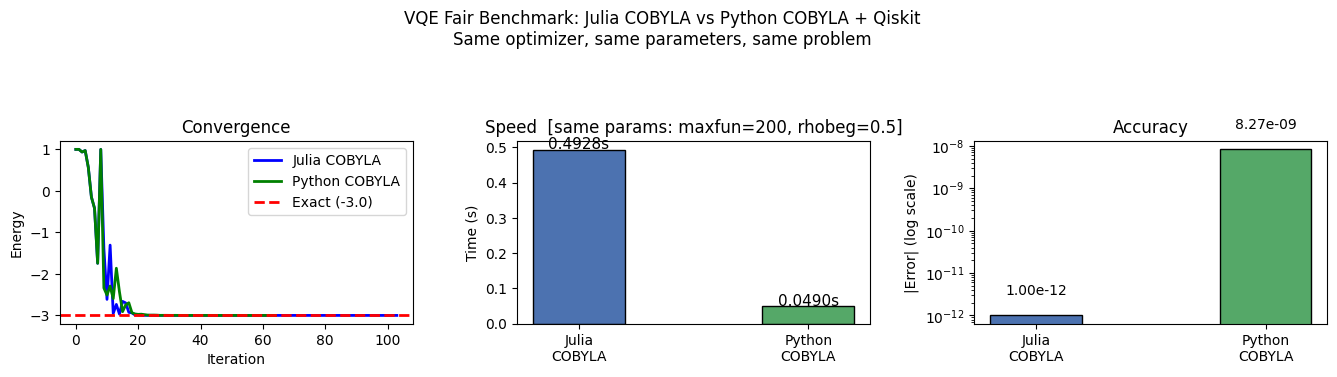

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ── Convergence ───────────────────────────────────────────────
axes[0].plot(j_history, 'b-', linewidth=2, label='Julia COBYLA')
axes[0].plot(p_history, 'g-', linewidth=2, label='Python COBYLA')
axes[0].axhline(-3.0, color='red', linestyle='--', linewidth=2, label='Exact (-3.0)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Energy')
axes[0].set_title('Convergence')
axes[0].legend()

# ── Speed ─────────────────────────────────────────────────────
labels = ['Julia\nCOBYLA', 'Python\nCOBYLA']
times  = [j_time, p_time]
colors = ['#4C72B0', '#55A868']
bars   = axes[1].bar(labels, times, color=colors, edgecolor='black', width=0.4)
axes[1].set_ylabel('Time (s)')
axes[1].set_title(f'Speed  [same params: maxfun=200, rhobeg=0.5]')
for bar, v in zip(bars, times):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 0.003, f'{v:.4f}s', ha='center', fontsize=11)

# ── Accuracy ──────────────────────────────────────────────────
errors = [abs(j_energy - (-3.0)) + 1e-12,
          abs(p_energy - (-3.0)) + 1e-12]
bars2  = axes[2].bar(labels, errors, color=colors, edgecolor='black', width=0.4)
axes[2].set_yscale('log')
axes[2].set_ylabel('|Error| (log scale)')
axes[2].set_title('Accuracy')
for bar, v in zip(bars2, errors):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 v * 3, f'{v:.2e}', ha='center', fontsize=10)

plt.suptitle('VQE Fair Benchmark: Julia COBYLA vs Python COBYLA + Qiskit\n'
             'Same optimizer, same parameters, same problem',
             fontsize=12)
plt.tight_layout(pad=2.5)
plt.savefig("vqe_cobyla_comparison.png", dpi=150, bbox_inches='tight')
plt.show()